## TSB-AD Quick Start

### Run AD Model

In this tutorial, we demonstrate how to (i) load a univariate or multivariate time series from the TSB-AD benchmark, (ii) run an unsupervised anomaly detector, and (iii) evaluate its detection quality using standard measures.

Citation: https://github.com/thedatumorg/TSB-AD/blob/main/tutorials/a_quick_start.ipynb

In [27]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np

import pandas as pd
from TSB_AD.model_wrapper import run_Unsupervise_AD
from TSB_AD.evaluation.metrics import get_metrics
from pyod.models.ts_kshape import KShape
import matplotlib.pyplot as plt
from pyod.models.ts_od import TimeSeriesOD
from TSB_AD.evaluation.basic_metrics import basic_metricor

In [42]:
data_direc = 'Datasets/TSB-AD-U/001_NAB_id_1_Facility_tr_1007_1st_2014.csv'

# Loading Data
df = pd.read_csv(data_direc).dropna()
data = df.iloc[:, 0:-1].values.astype(float)
label = df['Label'].astype(int).to_numpy()

#Get anomaly range:
grader = basic_metricor()
range_anomaly = grader.range_convers_new(label)

X_train = data[:1007]

## KShape

In [ ]:


clf = KShape(window_size=20)
clf.fit(X_train)
scores = clf.decision_scores_
print(scores)




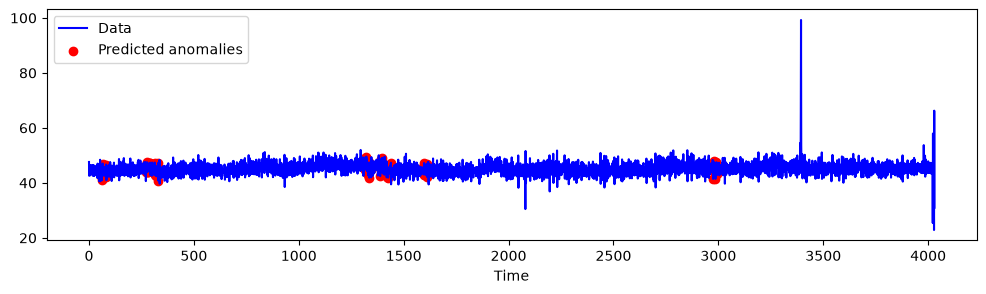

In [7]:
threshold = np.percentile(scores, 95)
anomaly_mask = scores > threshold
anomaly_idx = np.where(anomaly_mask)[0]

plt.figure(figsize=(12, 3))
plt.plot(range(len(data)), data, color='blue', label='Data')

plt.scatter(anomaly_idx, data[anomaly_idx], color='red', label='Predicted anomalies')

plt.legend()
plt.xlabel('Time')
plt.show()


## IForest (TD_OD)

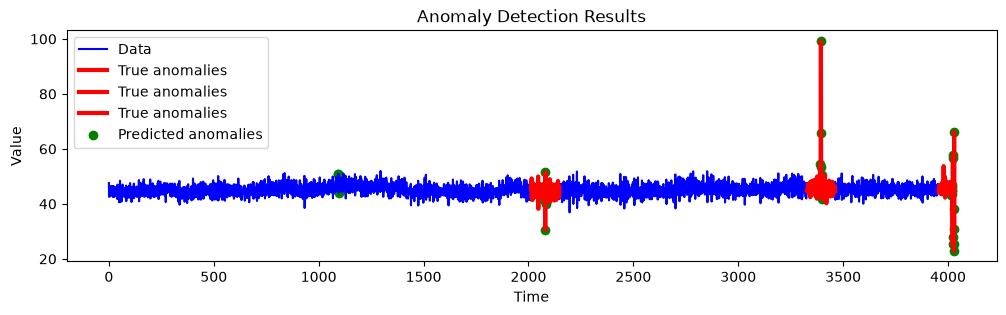

In [64]:
clf = TimeSeriesOD(
    detector="KNN",
    window_size=10,
    step=1,
    score_aggregation="max",
    contamination=0.01,
)

#clf.fit(X_train)
clf.fit(X_train)
scores = clf.decision_function(data)
threshold = np.percentile(scores[:2014], 99)
predicted = scores > threshold
anomaly_idx = np.where(predicted)[0]

plt.figure(figsize=(12,3))
plt.plot(range(len(data)), data, color='blue', label='Data')
for r in range_anomaly:
    if r[0] == r[1]:
        plt.scatter(r[0], data[r[0]], color='red', s=80, alpha=0.7)
    else:
        plt.plot(range(r[0], r[1]+1), data[r[0]:r[1]+1], color='red', linewidth=3, label='True anomalies')

plt.scatter(anomaly_idx, data[anomaly_idx], color='green', label='Predicted anomalies')

plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Anomaly Detection Results')
plt.legend()
plt.show()




## Plot anomaly scores

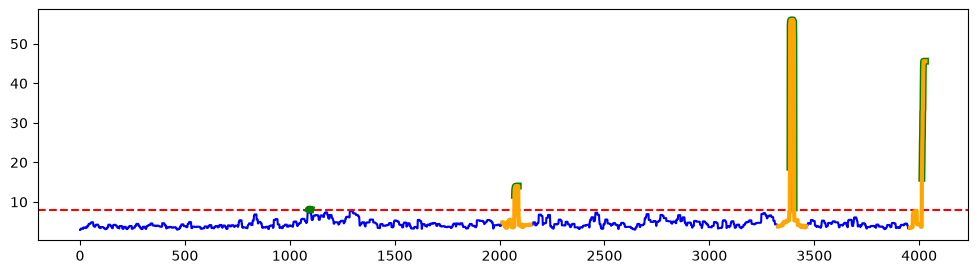

In [65]:
plt.figure(figsize=(12, 3))

pred_range_anomaly = grader.range_convers_new(predicted.astype(int))

plt.plot(range(len(data)), scores, color='blue', label='Data')
plt.axhline(y=threshold, color='red', linestyle='--', label='Threshold')
for r in pred_range_anomaly:
    if r[0] == r[1]:
        plt.scatter(r[0], scores[r[0]], color='green', s=80, alpha=0.7, label='Predicted anomalies')
    else:
        plt.plot(range(r[0], r[1]+1), scores[r[0]:r[1]+1], color='green', linewidth=5, label='Predicted anomalies')

#Real anomalies
for r in range_anomaly:
    if r[0] == r[1]:
        plt.scatter(r[0], scores[r[0]], color='orange', s=80, alpha=0.7, label='True anomalies')
    else:
        plt.plot(range(r[0], r[1]+1), scores[r[0]:r[1]+1], color='orange', linewidth=3, label='True anomalies')



## (True anomaly plot format)

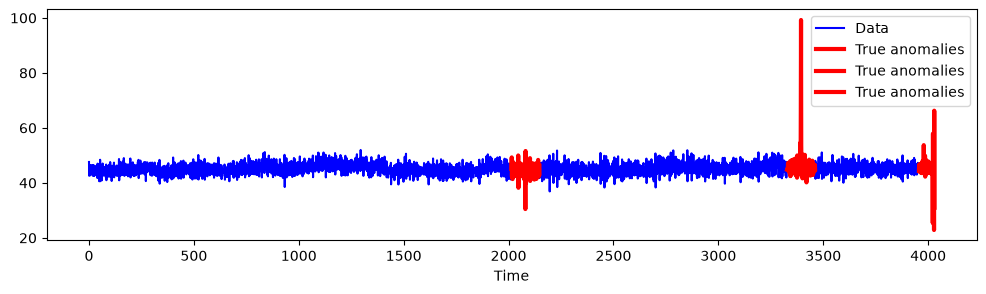

In [30]:
plt.figure(figsize=(12, 3))
plt.plot(range(len(data)), data, color='blue', label='Data')

for r in range_anomaly:
    if r[0] == r[1]:
        plt.scatter(r[0], data[r[0]], color='red', s=80, alpha=0.7, label='True anomalies')
    else:
        plt.plot(range(r[0], r[1]+1), data[r[0]:r[1]+1], color='red', linewidth=3, label='True anomalies')
plt.legend()
plt.xlabel('Time')
plt.show()

### Plot Time Series with Ground Truth Anomalies

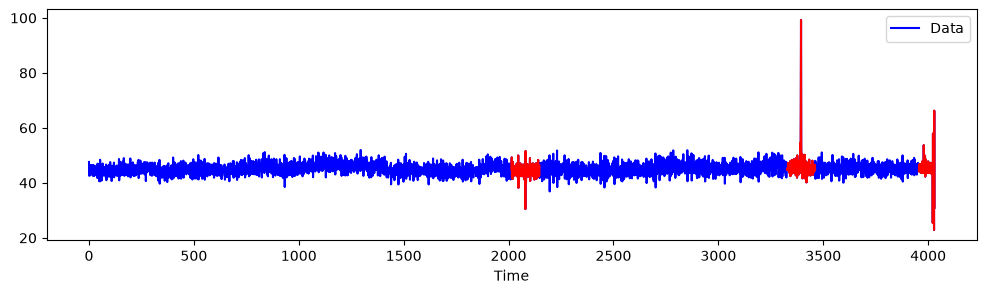

In [ ]:
import matplotlib.pyplot as plt


grader = basic_metricor()
range_anomaly = grader.range_convers_new(label)
fig, ax = plt.subplots(figsize=(12, 3))  # Adjust the figure size as needed
ax.plot(range(len(data)), data, color='blue', linewidth=1.5, label='Data')
for r in range_anomaly:
    if r[0] == r[1]:
        ax.plot(r[0], data[r[0]], 'ro', markersize=10)
    else:
        ax.plot(range(r[0], r[1] + 1), data[r[0]:r[1] + 1], color='red', linewidth=1.5) 
plt.legend()
plt.xlabel('Time')
plt.show()

# Systematic model eval

### Load data

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
)

train_end = 1007
test_start = 2014


models = [
    "IForest",
    "KNN",
    "ECOD",
    "COPOD",
    "HBOS",
    "LOF"
]

results = []

for model in models:
    clf = TimeSeriesOD(
        detector=model,
        window_size=10,
        step=1,
        score_aggregation="max",
        contamination=0.01,
    )
    clf.fit(data[:train_end])
    all_scores = clf.decision_function(data)

    # Apply the same calibration method to every model
    threshold = np.percentile(
        all_scores[train_end:test_start],
        99.0,
    )

    scores = all_scores[test_start:]
    predicted = scores > threshold

    test_label = label[test_start:]
    results.append({
        "Model": model,
        "Precision": precision_score(test_label, predicted, zero_division=0),
        "Recall": recall_score(test_label, predicted, zero_division=0),
        "F1": f1_score(test_label, predicted, zero_division=0),
        "ROC AUC": roc_auc_score(test_label, scores),
        "PR AUC": average_precision_score(test_label, scores),
        "Predictions": predicted.sum()
    })


results_df = pd.DataFrame(results)
results_df.sort_values("F1", ascending=False)


TypeError: string indices must be integers, not 'str'

IForest : 0.16085790884718498
KNN : 0.2892768079800499
ECOD : 0.24311926605504589


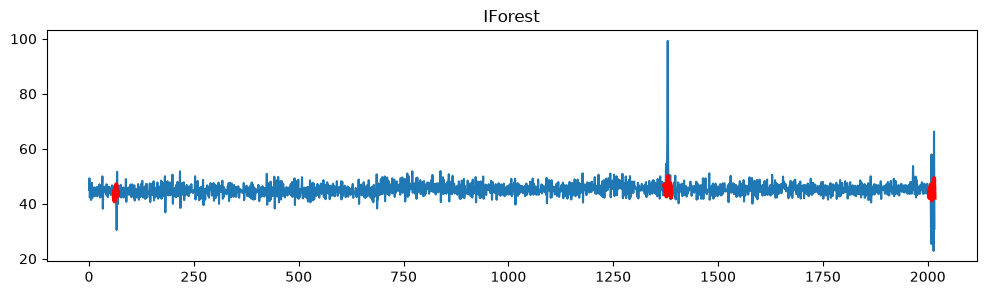

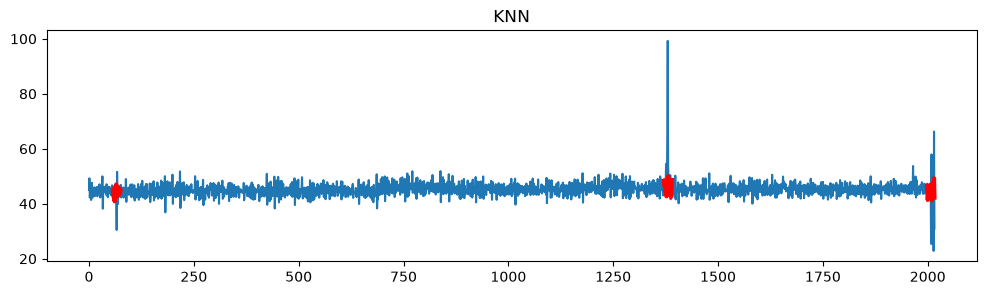

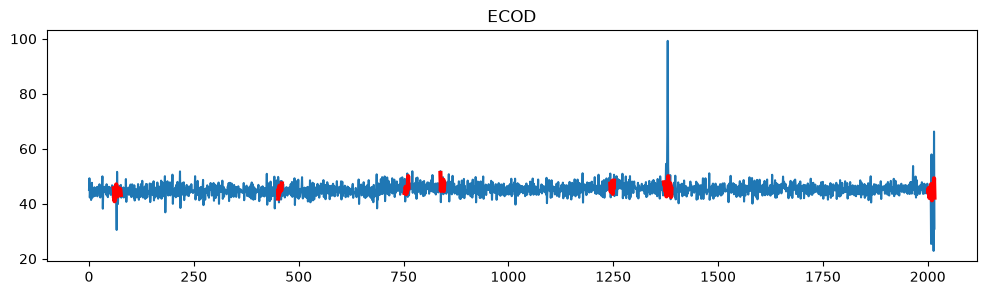

In [ ]:
best_results = results_df.head(3)
for _, result in best_results.iterrows():
    print(result["Model"], ":", result["F1"])

    plt.figure(figsize=(12,3))
    plt.plot(range(len(data[test_start:])), data[test_start:])

    clf = TimeSeriesOD(
        detector=result["Model"],
        window_size=10,
        step=1,
        score_aggregation="max",
        contamination=0.01,
    )
    clf.fit(data[:train_end])
    all_scores = clf.decision_function(data)

    # Apply the same calibration method to every model
    threshold = np.percentile(
        all_scores[train_end:test_start],
        99.0,
    )

    scores = all_scores[test_start:]
    predicted = scores > threshold

    anom_ranges = grader.range_convers_new(predicted.astype(int))
    for r in anom_ranges:

        if r[0] == r[1]:
            plt.scatter(r[0], data[r[0]], color="red")
        else:
            plt.plot(range(r[0], r[1]+1), data[r[0]:r[1]+1], color='red', linewidth=3, label='True anomalies')
        plt.title(result["Model"])

